1. Fetching Real-World Health Data (Patient Records)...
Data loaded: 768 patient records with 9 medical features.

2. Cleaning impossible medical data...
Cleaned! Replaced missing physiological zeroes with column medians.

3. Generating Health Insights Dashboard...


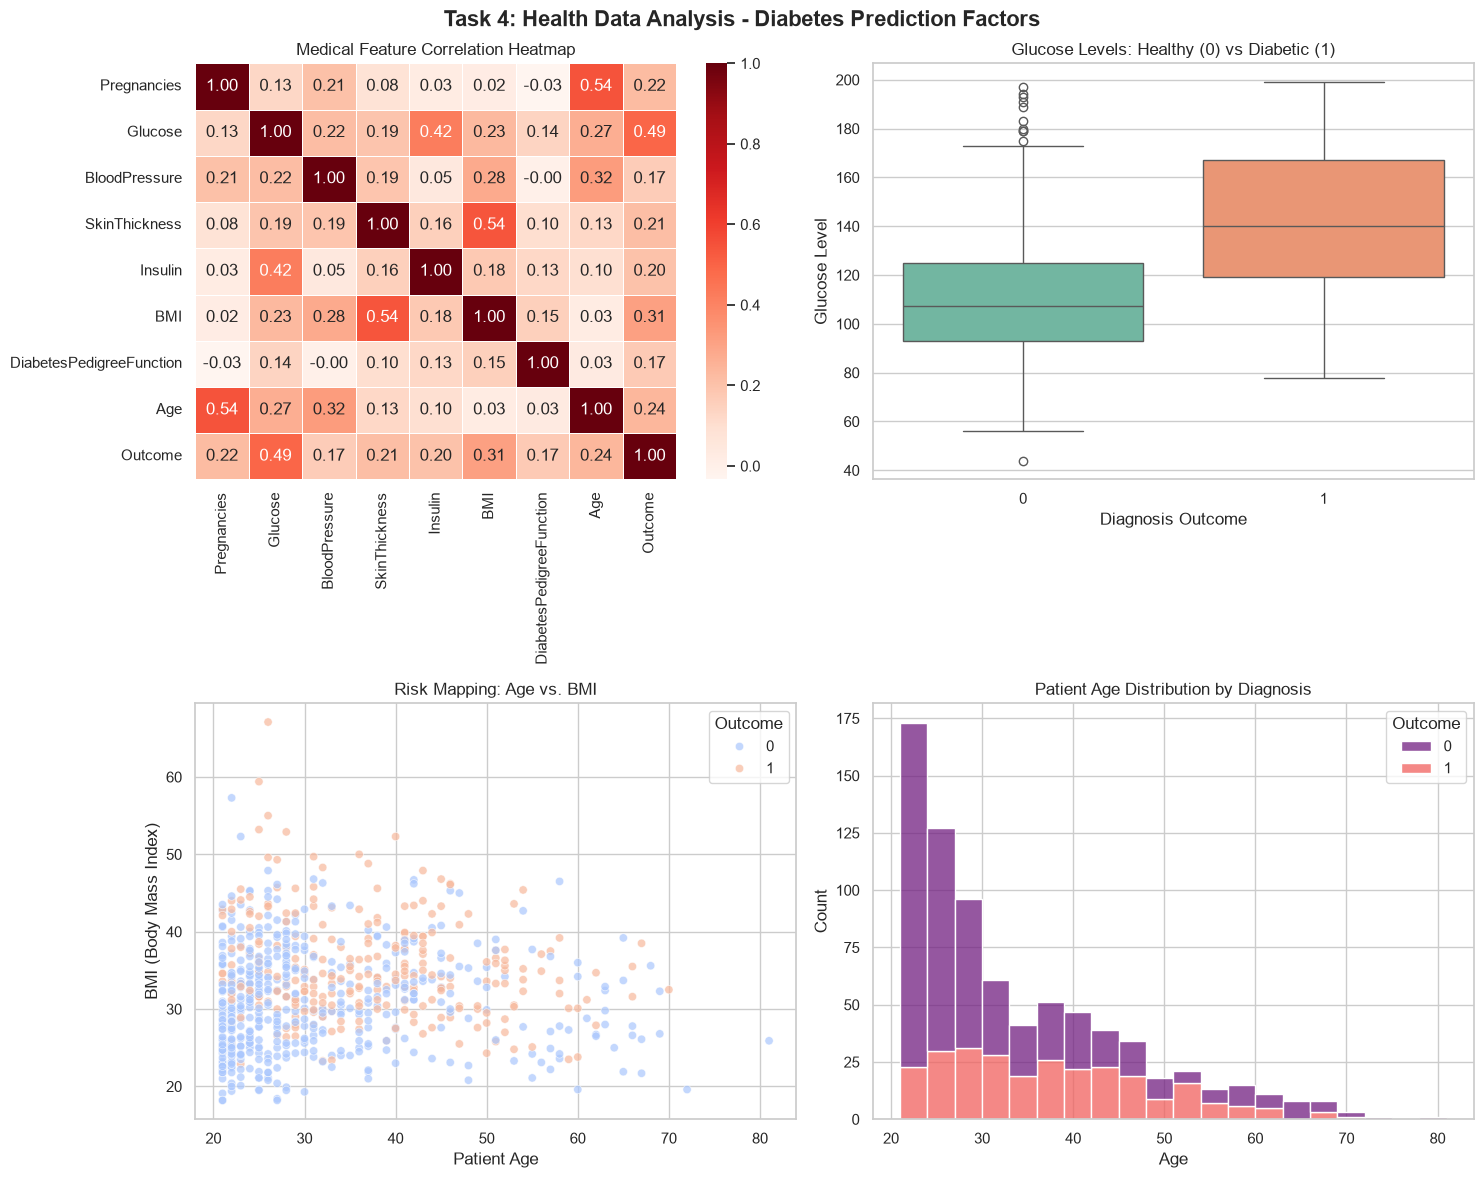


Task complete! Processed data saved as 'cleaned_patient_records.csv'.
Dashboard saved as 'health_insights_dashboard.png'.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Keep the output clean for the final submission screenshots
warnings.filterwarnings('ignore')

print("1. Fetching Real-World Health Data (Patient Records)...")
# Using a reliable public URL for the Diabetes dataset
url = "https://raw.githubusercontent.com/plotly/datasets/master/diabetes.csv"
df = pd.read_csv(url)
print(f"Data loaded: {df.shape[0]} patient records with {df.shape[1]} medical features.")

# ---------------------------------------------------------
# 2. DATA CLEANING & APPLIED LOGIC
# ---------------------------------------------------------
print("\n2. Cleaning impossible medical data...")
# A blood pressure or BMI of 0 means the data wasn't recorded, not that it's actually zero.
# We need to replace these 0s with NaN, then fill them with the median so it doesn't ruin our analysis.
columns_with_invalid_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

for col in columns_with_invalid_zeros:
    # Replace 0 with NaN
    df[col] = df[col].replace(0, np.nan)
    # Fill NaN with the median of that specific column
    df[col] = df[col].fillna(df[col].median())

print("Cleaned! Replaced missing physiological zeroes with column medians.")

# ---------------------------------------------------------
# 3. END-TO-END ANALYSIS & VISUALIZATION
# ---------------------------------------------------------
print("\n3. Generating Health Insights Dashboard...")
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle("Task 4: Health Data Analysis - Diabetes Prediction Factors", fontsize=16, fontweight="bold")

# Chart A: What has the highest correlation with Diabetes?
# Outcome 1 = Diabetic, 0 = Healthy
sns.heatmap(ax=axes[0, 0], data=df.corr(), annot=True, cmap="Reds", fmt=".2f", linewidths=0.5)
axes[0, 0].set_title("Medical Feature Correlation Heatmap")

# Chart B: Glucose Levels vs Outcome
# Boxplot shows how much higher glucose levels are in diabetic patients
sns.boxplot(ax=axes[0, 1], data=df, x="Outcome", y="Glucose", palette="Set2")
axes[0, 1].set_title("Glucose Levels: Healthy (0) vs Diabetic (1)")
axes[0, 1].set_xlabel("Diagnosis Outcome")
axes[0, 1].set_ylabel("Glucose Level")

# Chart C: Age and BMI Relationship
sns.scatterplot(ax=axes[1, 0], data=df, x="Age", y="BMI", hue="Outcome", palette="coolwarm", alpha=0.7)
axes[1, 0].set_title("Risk Mapping: Age vs. BMI")
axes[1, 0].set_xlabel("Patient Age")
axes[1, 0].set_ylabel("BMI (Body Mass Index)")

# Chart D: Age Distribution of Patients
sns.histplot(ax=axes[1, 1], data=df, x="Age", hue="Outcome", multiple="stack", palette="magma", bins=20)
axes[1, 1].set_title("Patient Age Distribution by Diagnosis")
axes[1, 1].set_xlabel("Age")

plt.tight_layout()
plt.savefig("health_insights_dashboard.png", dpi=300)
plt.show()

# 4. EXPORT CLEANED DATA
df.to_csv("cleaned_patient_records.csv", index=False)
print("\nTask complete! Processed data saved as 'cleaned_patient_records.csv'.")
print("Dashboard saved as 'health_insights_dashboard.png'.")